In [1]:
import pandas as pd

In [2]:
happiness = pd.read_csv("../data/happiness.csv")
income = pd.read_csv("../data/income.csv")
house = pd.read_csv("../data/house_price.csv")

happiness.head()

,city,happiness
0,Beijing,91.61
1,Shanghai,95.00
2,Tianjin,65.56
3,Chongqing,68.63
4,Guangzhou,82.16


In [3]:
df = happiness.merge(income, on="city").merge(house, on="city")
df

,city,happiness,income,house_price
0,Beijing,91.61,181438,48492
1,Shanghai,95.00,203863,61399
2,Tianjin,65.56,76008,11056
3,Chongqing,68.63,91580,11579
4,Guangzhou,82.16,138320,39415
...,...,...,...,...
295,City166,67.52,92123,9488
296,City167,72.17,95434,13936
297,City168,74.93,90807,14998
298,City169,70.83,79579,13598


In [4]:
df["value_index"] = df["income"] / df["house_price"]
df

,city,happiness,income,house_price,value_index
0,Beijing,91.61,181438,48492,3.741607
1,Shanghai,95.00,203863,61399,3.320298
2,Tianjin,65.56,76008,11056,6.874819
3,Chongqing,68.63,91580,11579,7.909146
4,Guangzhou,82.16,138320,39415,3.509324
...,...,...,...,...,...
295,City166,67.52,92123,9488,9.709422
296,City167,72.17,95434,13936,6.848020
297,City168,74.93,90807,14998,6.054607
298,City169,70.83,79579,13598,5.852258


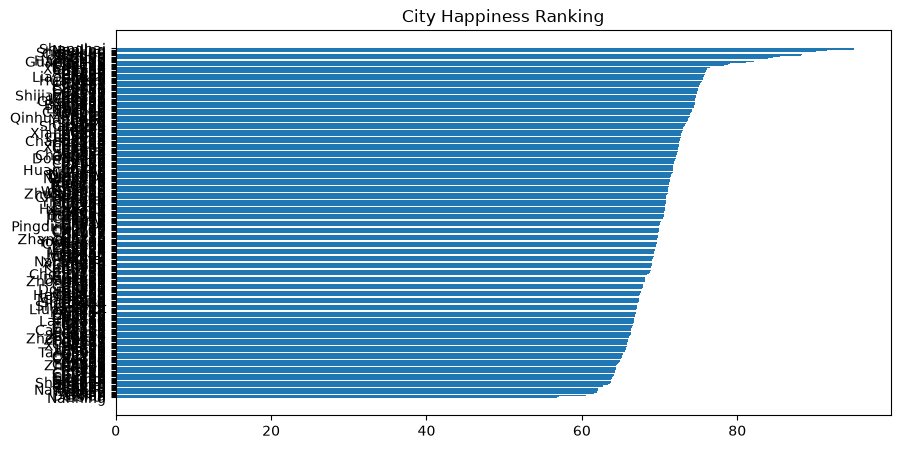

In [5]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values("happiness")

plt.figure(figsize=(10,5))
plt.barh(df_sorted["city"], df_sorted["happiness"])
plt.title("City Happiness Ranking")
plt.show()

In [6]:
df["value_index"] = df["income"] / df["house_price"]
df

,city,happiness,income,house_price,value_index
0,Beijing,91.61,181438,48492,3.741607
1,Shanghai,95.00,203863,61399,3.320298
2,Tianjin,65.56,76008,11056,6.874819
3,Chongqing,68.63,91580,11579,7.909146
4,Guangzhou,82.16,138320,39415,3.509324
...,...,...,...,...,...
295,City166,67.52,92123,9488,9.709422
296,City167,72.17,95434,13936,6.848020
297,City168,74.93,90807,14998,6.054607
298,City169,70.83,79579,13598,5.852258


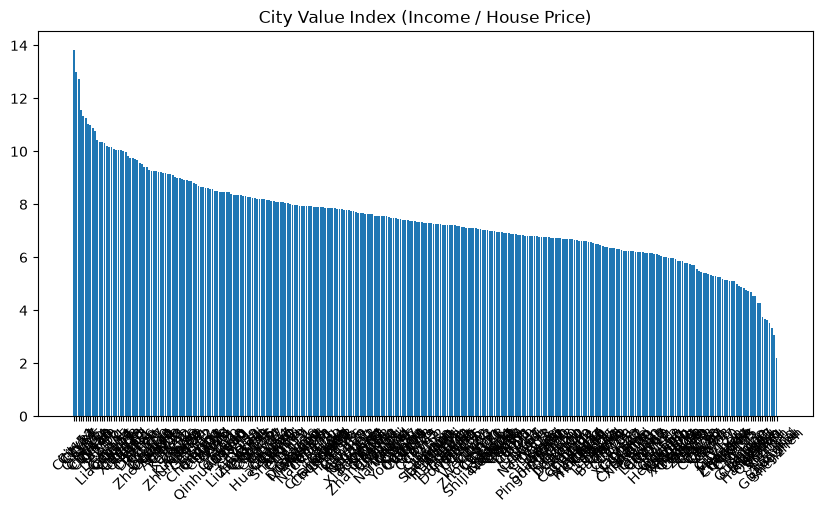

In [7]:
top = df.sort_values("value_index", ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.bar(top["city"], top["value_index"])
plt.title("City Value Index (Income / House Price)")
plt.xticks(rotation=45)
plt.show()

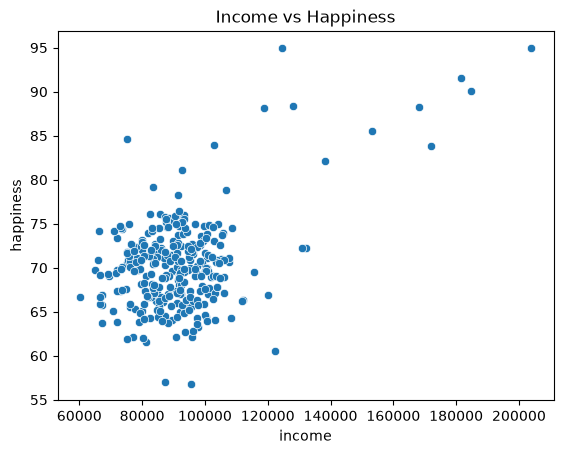

In [8]:
import seaborn as sns

sns.scatterplot(data=df, x="income", y="happiness")
plt.title("Income vs Happiness")
plt.show()

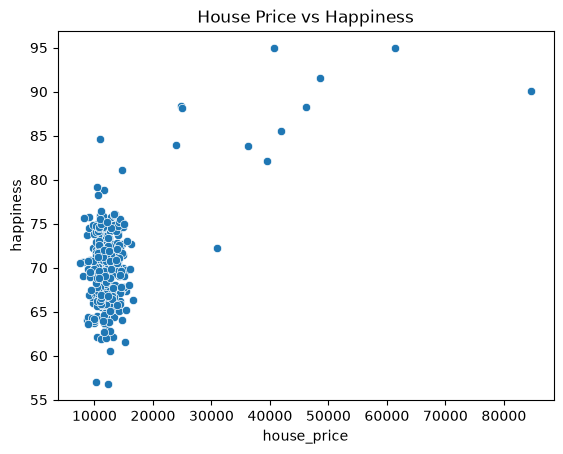

In [9]:
sns.scatterplot(data=df, x="house_price", y="happiness")
plt.title("House Price vs Happiness")
plt.show()

In [10]:
from pyecharts.charts import Map
from pyecharts import options as opts

map_data = list(zip(df["city"], df["happiness"]))

m = Map()
m.add("Happiness", map_data, "china")

m.set_global_opts(
    title_opts=opts.TitleOpts(title="China City Happiness Map"),

    visualmap_opts=opts.VisualMapOpts(
        min_=6.5,
        max_=7.5,
        is_piecewise=True,
        pieces=[
            {"min": 7.3, "label": "Very High"},
            {"min": 7.0, "max": 7.3, "label": "High"},
            {"min": 6.8, "max": 7.0, "label": "Medium"},
            {"max": 6.8, "label": "Low"},
        ]
    ),

    tooltip_opts=opts.TooltipOpts(formatter="{b}: {c}")
)

m.set_series_opts(
    label_opts=opts.LabelOpts(is_show=False)
)

m.render("happiness_map_v3.html")

'c:\\Users\\86132\\Desktop\\中国城市生活成本与幸福感分析可视化\\notebooks\\happiness_map_v3.html'